In [3]:
import numpy as np
from matplotlib import pyplot as plt
import pickle as pkl

In [58]:
location1 = f'../data/interim/dd4da095-4a99-4bf3-9727-f735077dba66_feedback_neuron'
location2 = f'../data/interim/dd4da095-4a99-4bf3-9727-f735077dba66_choice_neuron'

with open(location1,'rb') as f:
    x1 = pkl.load(f)

with open(location2,'rb') as f:
    x2 = pkl.load(f)

In [52]:
x.keys()

dict_keys(['MG', 'LP', 'PL', 'ORBm', 'VISam', 'MOs', 'ORBvl'])

In [53]:
x['VISam'].shape

(171, 8)

In [54]:
x['MG'].shape

(120, 8)

In [59]:
idx_1_A1 = np.mean(x1['VISam'], axis=0)
idx_1_A2 = np.mean(x1['MG'], axis=0)

idx_1_A1_std = np.std(x1['VISam'], axis=0)
idx_1_A2_std = np.std(x1['MG'], axis=0)



idx_2_A1 = np.mean(x2['VISam'], axis=0)
idx_2_A2 = np.mean(x2['MG'], axis=0)
idx_2_A1_std = np.std(x2['VISam'], axis=0)
idx_2_A2_std = np.std(x2['MG'], axis=0)

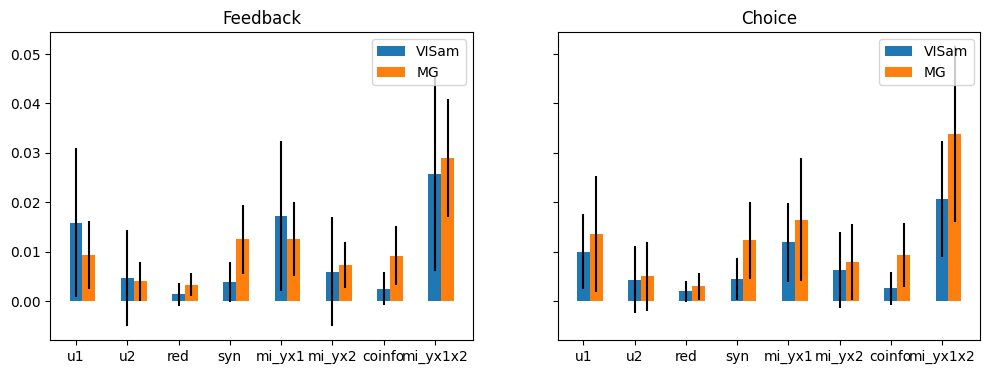

In [65]:
#ordering -> u1, u2, red, syn, mi_yx1, mi_yx2, coinfo, mi_yx1x2

labels = ['u1','u2','red','syn','mi_yx1','mi_yx2','coinfo','mi_yx1x2']


fig, ax = plt.subplots(ncols=2, sharey=True, figsize=(12,4))

ax[0].bar(np.arange(8), idx_1_A1, width=0.25, yerr=idx_1_A1_std/2,label='VISam')
ax[0].bar(np.arange(8)+0.25, idx_1_A2, width=0.25, yerr=idx_1_A2_std/2,label='MG')
ax[0].set_xticks(np.arange(8), labels=labels)
ax[0].set_title('Feedback')
ax[0].legend()


ax[1].bar(np.arange(8), idx_2_A1, width=0.25, yerr=idx_2_A1_std/2,label='VISam')
ax[1].bar(np.arange(8)+0.25, idx_2_A2, width=0.25, yerr=idx_2_A2_std/2,label='MG')
ax[1].set_xticks(np.arange(8), labels=labels)
ax[1].set_title('Choice')
ax[1].legend()





Remember to:
- `normalize by MI(Y, X1, X2) and then average`
- hierarchy plots


In [66]:
import pandas as pd

In [67]:
global_hierarchy = pd.read_csv('../data/processed/global_hierarchy.csv')

In [70]:
global_hierarchy[global_hierarchy['areas']=='VISam']


,areas,H-score,ordinal_rank
49,VISam,0.274742,49


In [71]:
global_hierarchy[global_hierarchy['areas']=='MG']

,areas,H-score,ordinal_rank
7,MG,-0.401778,7


In [80]:
R_visam = x1['VISam'][:,2]/x1['VISam'][:,7]
S_visam = x1['VISam'][:,3]/x1['VISam'][:,7]

C:\Users\debot\AppData\Local\Temp\ipykernel_16716\3483526058.py:1: RuntimeWarning: divide by zero encountered in divide
  R_visam = x1['VISam'][:,2]/x1['VISam'][:,7]
C:\Users\debot\AppData\Local\Temp\ipykernel_16716\3483526058.py:2: RuntimeWarning: divide by zero encountered in divide
  S_visam = x1['VISam'][:,3]/x1['VISam'][:,7]


In [87]:
R_MG = x2['VISam'][:,2]/x2['VISam'][:,7]
S_MG = x2['VISam'][:,3]/x2['VISam'][:,7]

C:\Users\debot\AppData\Local\Temp\ipykernel_16716\2834683565.py:1: RuntimeWarning: divide by zero encountered in divide
  R_MG = x2['VISam'][:,2]/x2['VISam'][:,7]
C:\Users\debot\AppData\Local\Temp\ipykernel_16716\2834683565.py:2: RuntimeWarning: divide by zero encountered in divide
  S_MG = x2['VISam'][:,3]/x2['VISam'][:,7]


In [89]:
np.ma.masked_invalid(R_visam).mean(), np.ma.masked_invalid(S_visam).mean()


(0.02980430990028852, 0.12452406223119031)

In [88]:
np.ma.masked_invalid(R_MG).mean(), np.ma.masked_invalid(S_MG).mean()

(0.06754412120122386, 0.16063622828927404)

In [103]:
# now for plots

from glob import glob
from tqdm import tqdm_notebook

In [91]:
files = glob('../data/interim/all_normalization/*feedback*')

In [105]:
def gather_data(location, epoch):
    files = glob(f'{location}*{epoch}*')
    regions = {}
    # labels = ['u1','u2','red','syn','mi_yx1','mi_yx2','coinfo','mi_yx1x2']

    for each_file in tqdm_notebook(files):
        with open(each_file,'rb') as f:
            data = pkl.load(f)  
        
        for k in data.keys():
            pid_region = data[k]
            # now for each region, we compute the mean syn and red
            mean_synergy = np.mean(pid_region,axis=0)[3]
            mean_redundancy = np.mean(pid_region,axis=0)[2]

            if k in regions.keys():
                regions[k].append([mean_synergy, mean_redundancy])
            else:
                regions[k] = [[mean_synergy, mean_redundancy]]
    return regions
    

In [106]:
feedback_data = gather_data('../data/interim/all_normalization/','feedback')

C:\Users\debot\AppData\Local\Temp\ipykernel_16716\1519097587.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for each_file in tqdm_notebook(files):


  0%|          | 0/22 [00:00<?, ?it/s]

In [120]:
feedback_data.keys()

dict_keys(['LGd', 'VISrl', 'AV', 'VAL', 'POL', 'VISp', 'RSPd', 'PO', 'VISa', 'VPM', 'SSp-bfd', 'SSp-tr', 'LP', 'VISpl', 'PL', 'ILA', 'ACAd', 'ORBl', 'FRP', 'MOs', 'AUDp', 'AUDd', 'SSs', 'LD', 'TEa', 'AM', 'SSp-ll', 'MD', 'RSPagl', 'CM', 'SSp-m', 'VPL', 'SSp-ul', 'SSp-n', 'VISl', 'VISli', 'VISpor', 'VISal', 'PVT', 'ACAv', 'PCN', 'MOp', 'MG', 'ORBm', 'VISam', 'ORBvl'])

In [122]:
def closest_factors(n):
    # Start at the square root of n
    sqrt_n = int(np.sqrt(n))
    
    # Check downward and upward from sqrt_n to find the closest factors
    for i in range(sqrt_n, 0, -1):
        if n % i == 0:
            # i is the smaller factor, n // i is the larger factor
            return i, n // i



In [161]:
# just do this manually
# 46 : 4*12

def plot_syn_red(data, epoch):
    total_regions = len(data.keys())

    pid_data_mean = np.zeros((total_regions, 2))
    pid_data_std = np.zeros((total_regions, 2))

    for idx, k in enumerate(data.keys()):
        temp = np.asarray(data[k])
        pid_data_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_std[idx, :] = np.mean(temp, axis=0)


    fig, ax = plt.subplots(figsize=(16,6))
    ax.bar(np.arange(total_regions), pid_data_mean[:, 0], width=0.25,label='Synergy')
    ax.bar(np.arange(total_regions)+0.25, pid_data_mean[:, 1], width=0.25, label='Redundancy')
    labels = list(data.keys())
    ax.set_xticks(np.arange(total_regions), labels, rotation=90)
    ax.set_title(f'Synergy-Redundancy for {epoch}')


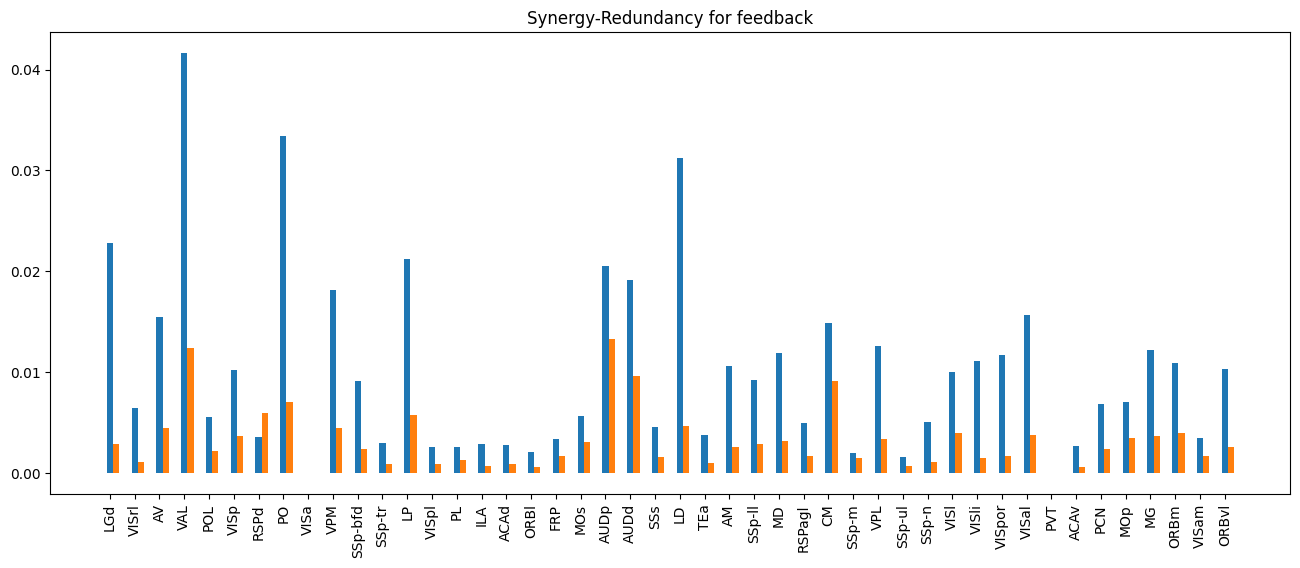

In [162]:
feedback_data = gather_data('../data/interim/all_normalization/','feedback')
plot_syn_red(feedback_data, 'feedback')

C:\Users\debot\AppData\Local\Temp\ipykernel_16716\1519097587.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for each_file in tqdm_notebook(files):


  0%|          | 0/22 [00:00<?, ?it/s]

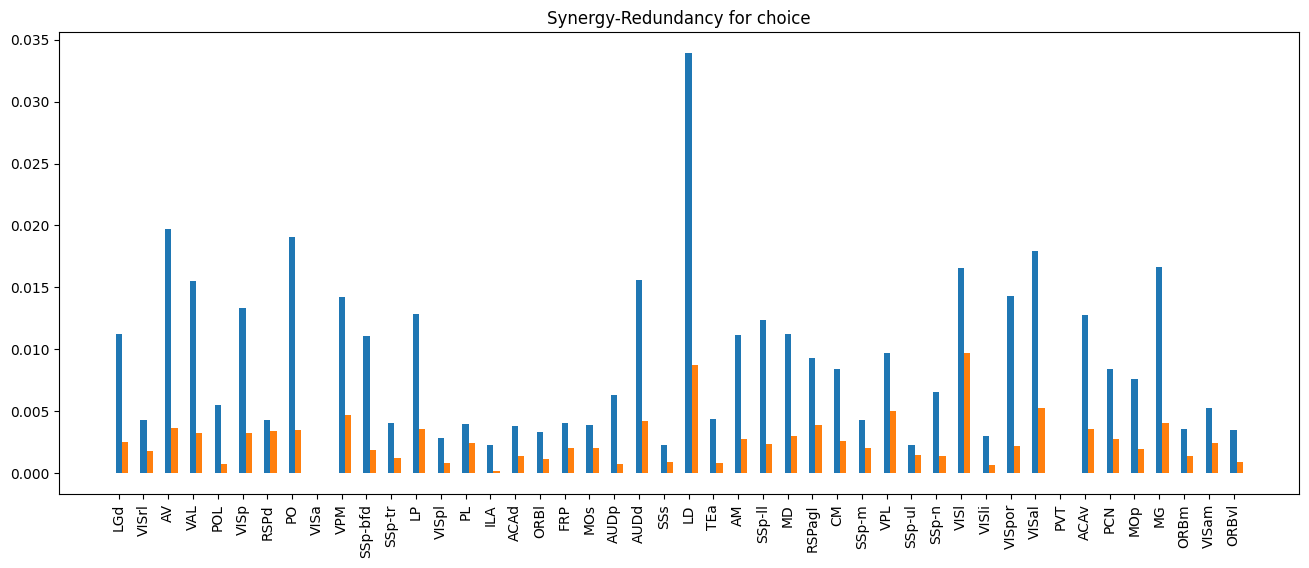

In [163]:
choice_data = gather_data('../data/interim/all_normalization/','choice')
plot_syn_red(choice_data, 'choice')

C:\Users\debot\AppData\Local\Temp\ipykernel_16716\1519097587.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for each_file in tqdm_notebook(files):


  0%|          | 0/22 [00:00<?, ?it/s]

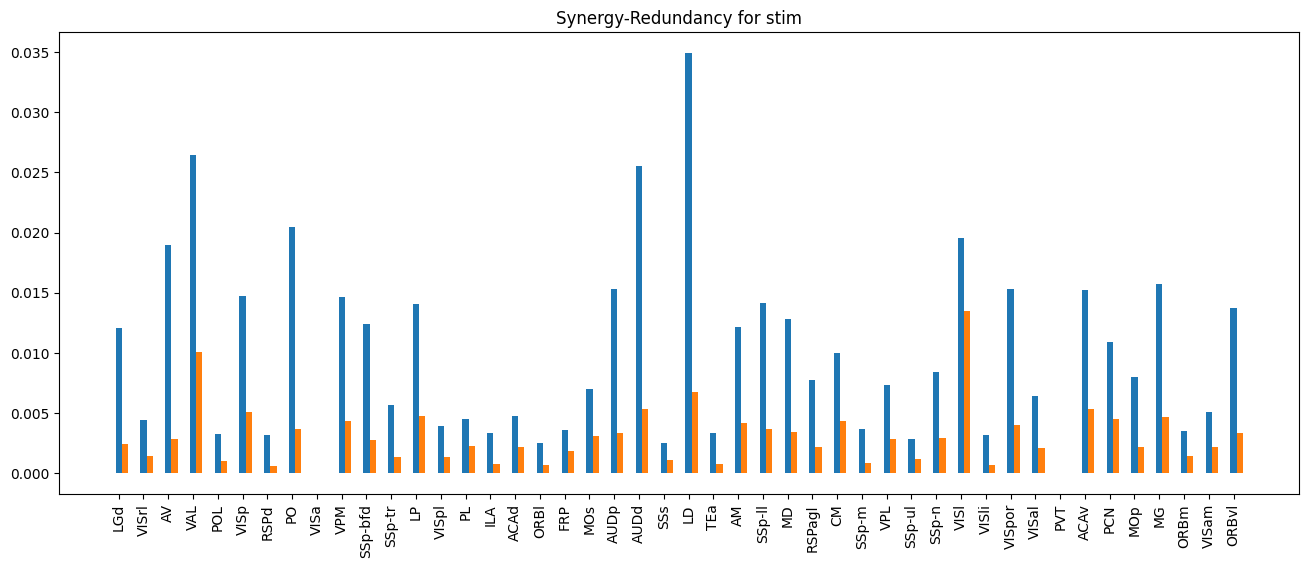

In [164]:
stim_data = gather_data('../data/interim/all_normalization/','stim')
plot_syn_red(stim_data, 'stim')

In [174]:
def reorder_subset(small_array, big_array):
    # Create a dictionary mapping each element in big_array to its index
    index_map = {value: index for index, value in enumerate(big_array)}
    
    # Sort small_array based on the index positions in big_array
    sorted_small_array = sorted(small_array, key=lambda x: index_map[x])
    sorted_indices = sorted(range(len(small_array)), key=lambda i: index_map[small_array[i]])
    
    return sorted_small_array, sorted_indices

In [175]:
X = global_hierarchy.areas.values
Y = np.asarray(list(stim_data.keys()))

In [176]:
Z, Z_idx = reorder_subset(Y, X)

In [182]:
def plot_syn_minus_red(data, epoch, sort_idx):
    total_regions = len(data.keys())

    pid_data_mean = np.zeros((total_regions, 2))
    pid_data_std = np.zeros((total_regions, 2))

    for idx, k in enumerate(data.keys()):
        temp = np.asarray(data[k])
        pid_data_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_std[idx, :] = np.mean(temp, axis=0)

    pid_data_mean = pid_data_mean[sort_idx, :]
    pid_data_std = pid_data_std[sort_idx, :]

    fig, ax = plt.subplots(figsize=(16,6))
    ax.scatter(np.arange(total_regions), pid_data_mean[:, 0]-pid_data_mean[:, 1],label='Synergy-Redundancy')
    # ax.bar(np.arange(total_regions)+0.25, , width=0.25, label='Redundancy')
    labels = np.asarray(list(data.keys()))
    ax.set_xticks(np.arange(total_regions), labels[sort_idx], rotation=90)
    ax.set_title(f'Synergy-Redundancy for {epoch}')


In [239]:
def get_mapping_to(df, areas):
    
    # get areas that have been made into ROIs
    regionwide = np.isin(areas, df['areas'])
    regionwide_areas = areas[regionwide]

    area_to_region = dict(zip(df['areas'], df['Region']))
    regions_array = np.array([area_to_region[area] for area in regionwide_areas])
    sort_idx = np.argsort(regions_array)

    return regionwide, sort_idx


In [398]:
def plot_epochs(data_a, data_b, data_c, df):

    #TODO: arg sort by bigger regions
    
    total_regions = len(data_a.keys())


    pid_data_a_mean = np.zeros((total_regions, 2))
    pid_data_a_std = np.zeros((total_regions, 2))
    pid_data_b_mean = np.zeros((total_regions, 2))
    pid_data_b_std = np.zeros((total_regions, 2))
    pid_data_c_mean = np.zeros((total_regions, 2))
    pid_data_c_std = np.zeros((total_regions, 2))

    for idx, k in enumerate(data_a.keys()):
        temp = np.asarray(data_a[k])
        pid_data_a_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_a_std[idx, :] = np.mean(temp, axis=0)

        temp = np.asarray(data_b[k])
        pid_data_b_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_b_std[idx, :] = np.mean(temp, axis=0)

        temp = np.asarray(data_c[k])
        pid_data_c_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_c_std[idx, :] = np.mean(temp, axis=0)
    

    # sort by region
    areas = np.asarray(list(data_a.keys()))
    regionwide, sort_idx = get_mapping_to(df, areas)
    total_regions = np.sum(regionwide)
    areas = areas[regionwide]

    fig, ax = plt.subplots(figsize=(16,6), nrows=2, sharex=True,layout='constrained')
    ax[0].bar(np.arange(total_regions)-0.3, pid_data_a_mean[regionwide, 0][sort_idx],label='Stim', width=0.3)
    ax[0].bar(np.arange(total_regions), pid_data_b_mean[regionwide, 0][sort_idx],label='Choice', width=0.3)
    ax[0].bar(np.arange(total_regions)+0.3, pid_data_c_mean[regionwide, 0][sort_idx],label='Feedback', width=0.3)
    # ax.bar(np.arange(total_regions)+0.25, pid_data_mean[regionwide, 1], width=0.25, label='Redundancy')
    labels = list(data_a.keys())
    ax[0].set_xticks(np.arange(total_regions), areas[sort_idx], rotation=90)
    ax[0].set_title(f'Synergy for all epochs')


    ax[1].bar(np.arange(total_regions)-0.3, pid_data_a_mean[regionwide, 1][sort_idx],label='Stim', width=0.3)
    ax[1].bar(np.arange(total_regions), pid_data_b_mean[regionwide, 1][sort_idx],label='Choice', width=0.3)
    ax[1].bar(np.arange(total_regions)+0.3, pid_data_c_mean[regionwide, 1][sort_idx],label='Feedback', width=0.3)
    # ax.bar(np.arange(total_regions)+0.25, pid_data_mean[:, 1], width=0.25, label='Redundancy')
    ax[1].set_xticks(np.arange(total_regions), areas[sort_idx], rotation=90)
    ax[1].set_title(f'Redundancy for all epochs')
    plt.legend()
    # needed for second axis
    area_to_region = dict(zip(df['areas'], df['Region']))

    
    regions = np.array([area_to_region[a] for a in areas[sort_idx]])

    values = ['\n\n\n\n'+v for v in regions]
    sec = ax[1].secondary_xaxis(location='top')
    
    sec.set_xticks(np.arange(len(regions))-0.5, labels=values,rotation=90)
    sec.tick_params('x', length=0)
    # ax[1].xaxis.set_xticks(np.arange(len(regions)))
    # ax[1].xaxis.set_xticklabels(regions, rotation=0)
    # ax[1].xaxis.set_xlim(ax[1].get_xlim())


    


In [399]:
df = pd.read_csv('../data/processed/region_mapping.csv')

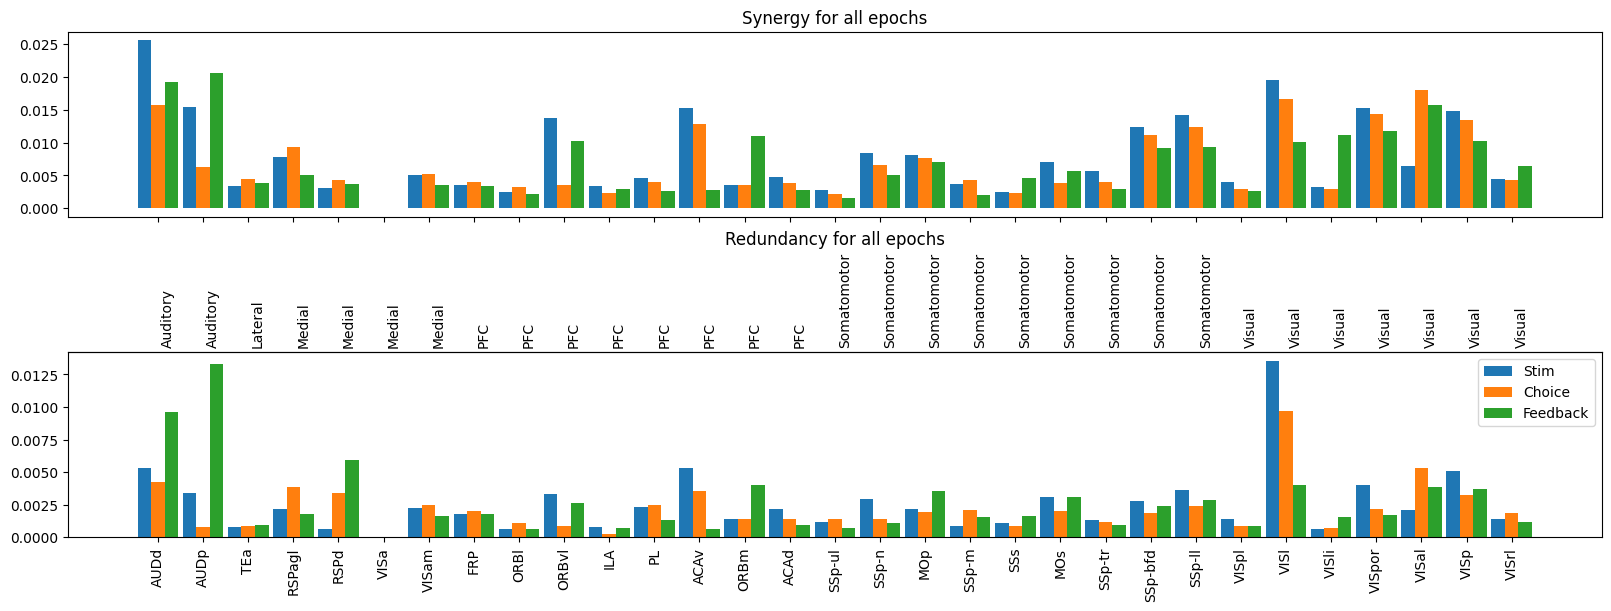

In [400]:
plot_epochs(stim_data, choice_data, feedback_data, df)

In [342]:
values, counts = np.unique(regions, return_counts=True)

In [385]:
ax.secondary_xaxis?

Signature: ax.secondary_xaxis(location, *, functions=None, transform=None, **kwargs)
Docstring:
Add a second x-axis to this `~.axes.Axes`.

For example if we want to have a second scale for the data plotted on
the xaxis.


Warnings
--------
This method is experimental as of 3.1, and the API may change.

Parameters
----------
location : {'top', 'bottom', 'left', 'right'} or float
    The position to put the secondary axis.  Strings can be 'top' or
    'bottom' for orientation='x' and 'right' or 'left' for
    orientation='y'. A float indicates the relative position on the
    parent Axes to put the new Axes, 0.0 being the bottom (or left)
    and 1.0 being the top (or right).

functions : 2-tuple of func, or Transform with an inverse

    If a 2-tuple of functions, the user specifies the transform
    function and its inverse.  i.e.
    ``functions=(lambda x: 2 / x, lambda x: 2 / x)`` would be an
    reciprocal transform with a factor of 2. Both functions must accept
    numpy arrays as

array([ 1,  2,  6, 14, 23, 30], dtype=int64)

['\n\nAuditory',
 '\n\nLateral',
 '\n\nMedial',
 '\n\nPFC',
 '\n\nSomatomotor',
 '\n\nVisual']